# Session: Returns, Rolling Volatility, and Data Cleaning

## Goals

In this notebook, we will learn how to work with time series financial data.

By the end of this session, you should be able to:

1. Explain why data cleaning is important for machine learning and data projects
2. Understand what a Pandas DataFrame is
3. Inspect and clean a dataset
4. Calculate daily returns from stock prices
5. Calculate volatility as a risk measure
6. Calculate rolling volatility over time
7. Build a summary table comparing multiple stocks
8. Write observations from the analysis

## Expected Output

By the end, this notebook should contain:

- cleaned stock price data
- daily returns
- rolling volatility
- volatility plot
- summary table
- short written insights

# 1. Why Data Cleaning Matters

Before building any machine learning model or data analysis project, we must understand and clean the data.

A model does not understand the real world. It only understands the data we give it.

If the data is incorrect, incomplete, duplicated, or inconsistent, the model will learn wrong patterns.

A common phrase in machine learning is:

> Garbage in, garbage out.

This means bad input data produces bad results.

## Example: Missing Values

Suppose we have this dataset:

| Student | Score |
|---|---|
| Maya | 90 |
| Aarav | 85 |
| Riya | Missing |
| Kabir | 92 |

Can we calculate the average score correctly?

Not until we decide what to do with the missing value.

Options:
- remove that row
- fill the missing value
- investigate why the value is missing

Different choices can lead to different results.

## Example: Inconsistent Text

Suppose a column has these values:

```text
Male
male
MALE
```

A human understands these are the same category.

A computer sees them as three different values.

Before using this data, we should standardize it:

```text
male
male
male
```

# 2. What We Need to Understand About Any Dataset

Before cleaning or modeling data, we should ask important questions.

## What does each row represent?

| Dataset | One row represents |
|---|---|
| Stock data | one trading day |
| Customer data | one customer |
| Medical data | one patient |
| Sales data | one order |

If we do not know what a row means, we cannot correctly analyze the dataset.

## What does each column mean?

Example for stock data:

| Column | Meaning |
|---|---|
| Date | trading day |
| Open | price at market open |
| High | highest price that day |
| Low | lowest price that day |
| Close | final price at market close |
| Volume | number of shares traded |

Never use a column in analysis until you understand what it means.

## Other Questions to Ask

1. Is data missing?
2. Are there duplicate records?
3. Are there impossible values?
4. Are the units consistent?
5. Are the data types correct?
6. Does the dataset cover the time period we need?

# 3. Types of Data Cleaning

Data cleaning includes several different tasks.

## Handling Missing Values

```python
df.dropna()
```

Removes rows with missing values.

```python
df.fillna(value)
```

Fills missing values with a chosen value.

```python
df.ffill()
```

Forward fills missing values using the previous available value.

## Removing Duplicates

```python
df.drop_duplicates()
```

Removes repeated rows.

## Standardizing Text

```python
df["Name"] = df["Name"].str.strip().str.title()
df["Category"] = df["Category"].str.lower()
```

Useful for cleaning names, categories, cities, yes/no answers, and labels.

## Fixing Data Types

Sometimes numbers are stored as text.

```python
df["Score"] = df["Score"].astype(int)
```

## Handling Outliers

An outlier is a value that is very different from the rest.

Example:

| Salary |
|---|
| 50000 |
| 60000 |
| 70000 |
| 2000000 |

The value `2000000` may be correct, or it may be an error. We need to investigate before removing it.

# 4. What is Pandas?

Pandas is a Python library used for working with data.

You can think of Pandas as:

> Excel inside Python, but more powerful.

Pandas helps us:
- load data
- clean data
- filter rows
- calculate new columns
- create summary tables
- prepare data for machine learning

In [ ]:
import pandas as pd

# 5. What is a DataFrame?

A DataFrame is the main data structure in Pandas.

It looks like a table or spreadsheet.

Rows are observations. Columns are features or variables.

In [ ]:
df_example = pd.DataFrame({
    "Name": ["Maya", "Aarav", "Riya"],
    "Age": [16, 17, 15],
    "City": ["Toronto", "Vancouver", "Calgary"]
})

df_example

,Name,Age,City
0,Maya,16,Toronto
1,Aarav,17,Vancouver
2,Riya,15,Calgary


## Useful DataFrame Commands

These are some of the first commands we run when looking at a dataset.

In [ ]:
df_example.head(2)

,Name,Age,City
0,Maya,16,Toronto
1,Aarav,17,Vancouver


In [ ]:
df_example.shape

(3, 3)

In [ ]:
df_example.columns

Index(['Name', 'Age', 'City'], dtype='object')

In [ ]:
df_example.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    3 non-null      object
 1   Age     3 non-null      int64 
 2   City    3 non-null      object
dtypes: int64(1), object(2)
memory usage: 204.0+ bytes


In [ ]:
df_example.describe()

,Age
count,3.0
mean,16.0
std,1.0
min,15.0
25%,15.5
50%,16.0
75%,16.5
max,17.0


## Practice

Answer these questions using the DataFrame above:

1. How many rows are there?
2. How many columns are there?
3. What are the column names?
4. What data type is the `Age` column?

# 6. Understanding Daily Returns

A stock price tells us the value of one share.

But price alone does not tell us how well the stock performed.

To compare performance, we use returns.

## Why Raw Price Change Can Be Misleading

Suppose two stocks move like this:

| Stock | Start Price | End Price |
|---|---:|---:|
| Stock A | 50 | 60 |
| Stock B | 200 | 220 |

Stock B increased by 20 dollars. Stock A increased by 10 dollars.

But Stock A performed better because it increased by a larger percentage.

Stock A:

```text
(60 - 50) / 50 = 20%
```

Stock B:

```text
(220 - 200) / 200 = 10%
```

Returns help us compare different assets fairly.

## Daily Return Formula

Daily return compares today's price with yesterday's price.

```text
Return = (Today's Price - Yesterday's Price) / Yesterday's Price
```

Example:

| Day | Price |
|---|---:|
| Day 1 | 100 |
| Day 2 | 105 |
| Day 3 | 103 |

Day 2 return:

```text
(105 - 100) / 100 = 0.05 = 5%
```

Day 3 return:

```text
(103 - 105) / 105 = -0.019 = -1.9%
```

Returns can be positive, negative, or zero.

In [ ]:
prices = pd.Series([100, 105, 103, 108])
returns = prices.pct_change()
returns

,0
0,NaN
1,0.050000
2,-0.019048
3,0.048544


The first return is missing because there is no previous day to compare with.

# 7. Understanding Volatility

Return tells us how much an asset gained or lost.

Volatility tells us how unstable or risky those returns were.

In finance:

> Higher volatility usually means higher uncertainty or risk.

## Example: Same Average, Different Risk

Stock A returns:

```text
1%, 1%, 1%, 1%, 1%
```

Stock B returns:

```text
10%, -8%, 12%, -6%, -3%
```

Both may have a similar average return. But Stock B is much more volatile because its returns move up and down a lot.

## Volatility as Standard Deviation

Volatility is usually calculated as the standard deviation of returns.

Standard deviation measures how spread out values are from their average.

In [ ]:
stock_a_returns = pd.Series([0.01, 0.01, 0.01, 0.01, 0.01])
stock_b_returns = pd.Series([0.10, -0.08, 0.12, -0.06, -0.03])

print("Stock A average return:", stock_a_returns.mean())
print("Stock A volatility:", stock_a_returns.std())

print("Stock B average return:", stock_b_returns.mean())
print("Stock B volatility:", stock_b_returns.std())

Stock A average return: 0.01
Stock A volatility: 0.0
Stock B average return: 0.010000000000000004
Stock B volatility: 0.09327379053088815


# 8. Understanding Rolling Volatility

One volatility number summarizes the whole period.

But risk changes over time.

A stock may be calm during one month and very risky during another month.

Rolling volatility measures volatility over a moving window.

Example:

```python
df["RollingVolatility"] = df["Return"].rolling(window=20).std()
```

This means:

For each day, look back at the previous 20 trading days and calculate volatility.

A 20-day window is often used because it is roughly one trading month.

# 9. Practical Workflow: Load Financial Data

Now we will apply the concepts using real stock market data.

In [ ]:
# Uncomment and run this if yfinance is not installed
# !pip install yfinance

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statistics import mean

try:
    import yfinance as yf
    print("yfinance imported successfully")
except ImportError:
    print("yfinance is not installed. Run: !pip install yfinance")

yfinance imported successfully


# 10. Download Stock Data

We will start with Apple stock data.

In [ ]:
ticker = "AAPL"

df = yf.download(
    ticker,
    start="2023-01-01",
    end="2024-01-01",
    progress=False
)

df.head()

/tmp/ipykernel_5097/3617260995.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2023-01-03,122.982719,128.715417,122.097738,128.105769,112117500
2023-01-04,124.251198,126.512816,122.992561,124.772352,89113600
2023-01-05,122.933563,125.637669,122.677908,125.008350,80962700
2023-01-06,127.456749,128.115565,122.805693,123.907004,87754700
2023-01-09,127.977921,131.183524,127.722265,128.292587,70790800


## Discussion Questions

1. What does each row represent?
2. What does each column represent?
3. Why do we need dates for time series data?

# 11. Inspect the DataFrame

Before analysis, inspect the dataset.

In [ ]:
df.shape

(250, 5)

In [ ]:
df.columns

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 250 entries, 2023-01-03 to 2023-12-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   250 non-null    float64
 1   (High, AAPL)    250 non-null    float64
 2   (Low, AAPL)     250 non-null    float64
 3   (Open, AAPL)    250 non-null    float64
 4   (Volume, AAPL)  250 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.7 KB


In [ ]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,250.000000,250.000000,250.000000,250.000000,2.500000e+02
mean,170.194611,171.484989,168.649332,169.906602,5.922355e+07
std,17.308204,17.240177,17.506174,17.503787,1.778332e+07
min,122.933563,125.637669,122.097738,123.907004,2.404830e+07
25%,159.650402,159.921247,158.259372,159.101376,4.781208e+07
50%,173.282677,174.813311,171.668096,173.055542,5.511085e+07
75%,185.082829,185.714841,182.614864,184.222331,6.574292e+07
max,195.892609,197.385702,194.795061,195.803620,1.543573e+08


## Practice

Write answers in a markdown cell:

1. How many rows are in the dataset?
2. How many columns are in the dataset?
3. What is the average closing price?
4. What is the highest closing price?
5. What is the lowest closing price?

# 12. Clean the Data

Financial data from yfinance is usually clean, but we should still check it.

A reproducible notebook should always show the cleaning checks.

In [ ]:
df.isnull().sum()

,,0
Price,Ticker,
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0


In [ ]:
df = df.dropna()
df.isnull().sum()

,,0
Price,Ticker,
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()
df.shape

(250, 5)

In [ ]:
df.dtypes

,,0
Price,Ticker,
Close,AAPL,float64
High,AAPL,float64
Low,AAPL,float64
Open,AAPL,float64
Volume,AAPL,int64


## Cleaning Checklist

A good notebook should show:

```python
df.shape
df.isnull().sum()
df.duplicated().sum()
df.dtypes
```

This proves that we inspected the dataset before analysis.

# 13. Calculate Daily Returns

Now we calculate daily returns using the closing price.

In [ ]:
df["Return"] = df["Close"].pct_change()
df[["Close", "Return"]].head(10)

Price,Close,Return
Ticker,AAPL,
Date,,
2023-01-03,122.982719,NaN
2023-01-04,124.251198,0.010314
2023-01-05,122.933563,-0.010605
2023-01-06,127.456749,0.036794
2023-01-09,127.977921,0.004089
2023-01-10,128.548248,0.004456
2023-01-11,131.262222,0.021112
2023-01-12,131.183563,-0.000599


## Why is the first return missing?

The first row has no previous day to compare against.

That is why the first return is `NaN`.

In [ ]:
df["ReturnPct"] = df["Return"] * 100
df[["Close", "Return", "ReturnPct"]].head(10)

Price,Close,Return,ReturnPct
Ticker,AAPL,,
Date,,,
2023-01-03,122.982719,NaN,NaN
2023-01-04,124.251198,0.010314,1.031428
2023-01-05,122.933563,-0.010605,-1.060460
2023-01-06,127.456749,0.036794,3.679374
2023-01-09,127.977921,0.004089,0.408901
2023-01-10,128.548248,0.004456,0.445645
2023-01-11,131.262222,0.021112,2.111249
2023-01-12,131.183563,-0.000599,-0.059925


In [ ]:
df["ReturnPct"].describe()

,ReturnPct
count,249.000000
mean,0.183493
std,1.257004
min,-4.801986
25%,-0.589150
50%,0.187860
75%,0.884625
max,4.692699


## Practice

Find:

1. Average daily return
2. Best daily return
3. Worst daily return
4. The date of the best daily return
5. The date of the worst daily return

In [ ]:
average_return = df["Return"].mean()
best_return = df["Return"].max()
worst_return = df["Return"].min()

best_day = df["Return"].idxmax()
worst_day = df["Return"].idxmin()

print("Average daily return:", average_return)
print("Best daily return:", best_return)
print("Worst daily return:", worst_return)
print("Best day:", best_day)
print("Worst day:", worst_day)

Average daily return: 0.001834927242657081
Best daily return: 0.04692698648445437
Worst daily return: -0.048019862562669435
Best day: 2023-05-05 00:00:00
Worst day: 2023-08-04 00:00:00


# 14. Calculate Volatility

Volatility is the standard deviation of returns.

In [ ]:
volatility = df["Return"].std()

print("Daily volatility:", volatility)
print("Daily volatility percentage:", volatility * 100)

Daily volatility: 0.01257004062827745
Daily volatility percentage: 1.257004062827745


## Interpretation

If daily volatility is `0.015`, that means the stock typically moves around `1.5%` per day.

This does not mean the stock moves exactly 1.5% every day. It means the returns usually fluctuate around that level.

# 15. Calculate Rolling Volatility

Now we calculate 20-day rolling volatility.

In [ ]:
df["RollingVolatility20"] = df["Return"].rolling(window=20).std()
df[["Return", "RollingVolatility20"]].head(25)

Price,Return,RollingVolatility20
Ticker,,
Date,,
2023-01-03,NaN,NaN
2023-01-04,0.010314,NaN
2023-01-05,-0.010605,NaN
2023-01-06,0.036794,NaN
2023-01-09,0.004089,NaN
2023-01-10,0.004456,NaN
2023-01-11,0.021112,NaN
2023-01-12,-0.000599,NaN


The first 19 rows are missing because we need 20 days of returns before calculating the first 20-day rolling volatility value.

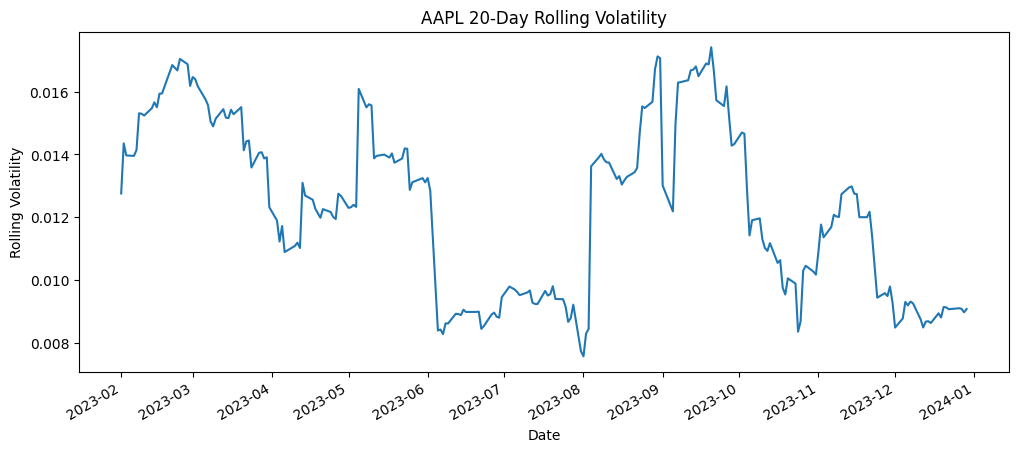

In [ ]:
plt.figure(figsize=(12, 5))
df["RollingVolatility20"].plot()
plt.title("AAPL 20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Rolling Volatility")
plt.show()

## Practice

Try different rolling windows:

- 5 days
- 20 days
- 60 days

Answer:

1. Which window is more sensitive?
2. Which window is smoother?
3. Why?

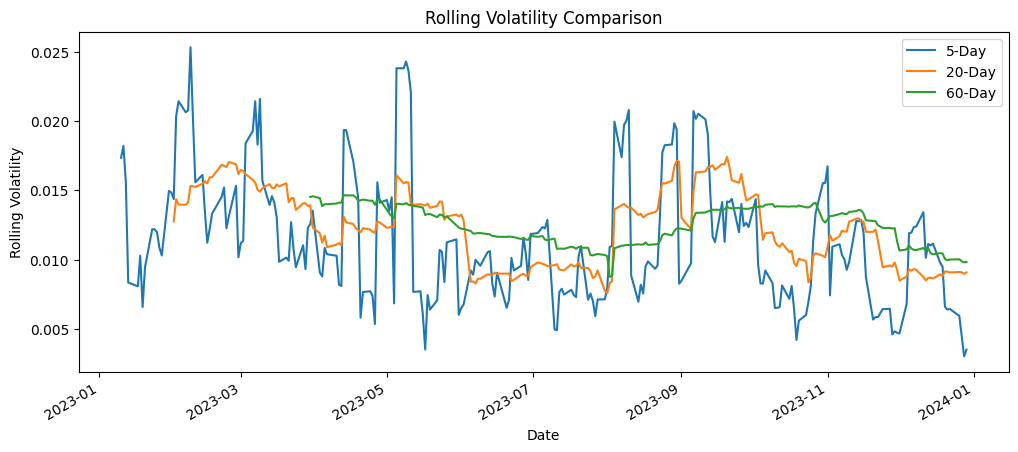

In [ ]:
df["RollingVolatility5"] = df["Return"].rolling(window=5).std()
df["RollingVolatility60"] = df["Return"].rolling(window=60).std()

plt.figure(figsize=(12, 5))
df["RollingVolatility5"].plot(label="5-Day")
df["RollingVolatility20"].plot(label="20-Day")
df["RollingVolatility60"].plot(label="60-Day")
plt.title("Rolling Volatility Comparison")
plt.xlabel("Date")
plt.ylabel("Rolling Volatility")
plt.legend()
plt.show()

# 16. Summary Table for One Stock

Analysts usually summarize results in tables.

In [ ]:
summary = pd.DataFrame({
    "Ticker": [ticker],
    "Average Return": [df["Return"].mean()],
    "Volatility": [df["Return"].std()],
    "Best Day Return": [df["Return"].max()],
    "Worst Day Return": [df["Return"].min()],
    "Average Close": [df["Close"].mean()]
})

summary

,Ticker,Average Return,Volatility,Best Day Return,Worst Day Return,Average Close
0,AAPL,0.001835,0.01257,0.046927,-0.04802,Ticker AAPL 170.194611 dtype: float64


# 17. Compare Multiple Stocks

Now we compare multiple stocks using the same process.

This is closer to a real analysis workflow.

In [ ]:
tickers = ["AAPL", "MSFT", "NVDA"]

summary_rows = []

for ticker in tickers:
    stock_df = yf.download(
        ticker,
        start="2023-01-01",
        end="2024-01-01",
        progress=False
    )

    stock_df = stock_df.dropna()
    stock_df = stock_df.drop_duplicates()

    stock_df["Return"] = stock_df["Close"].pct_change()
    stock_df["RollingVolatility20"] = stock_df["Return"].rolling(window=20).std()

    row = {
        "Ticker": ticker,
        "Average Return": stock_df["Return"].mean(),
        "Volatility": stock_df["Return"].std(),
        "Best Day Return": stock_df["Return"].max(),
        "Worst Day Return": stock_df["Return"].min(),
        "Average Close": stock_df["Close"].mean()
    }

    summary_rows.append(row)

summary_table = pd.DataFrame(summary_rows)
summary_table

/tmp/ipykernel_5097/3349402874.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_df = yf.download(
/tmp/ipykernel_5097/3349402874.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_df = yf.download(
/tmp/ipykernel_5097/3349402874.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_df = yf.download(


,Ticker,Average Return,Volatility,Best Day Return,Worst Day Return,Average Close
0,AAPL,0.001835,0.012570,0.046927,-0.048020,Ticker AAPL 170.194611 dtype: float64
1,MSFT,0.001972,0.015824,0.072435,-0.043743,Ticker MSFT 306.772868 dtype: float64
2,NVDA,0.005442,0.030525,0.243696,-0.059072,Ticker NVDA 36.497987 dtype: float64


## Make Percent Columns Easier to Read

In [ ]:
summary_table_display = summary_table.copy()

percent_columns = [
    "Average Return",
    "Volatility",
    "Best Day Return",
    "Worst Day Return"
]

for col in percent_columns:
    summary_table_display[col] = summary_table_display[col] * 100

summary_table_display

,Ticker,Average Return,Volatility,Best Day Return,Worst Day Return,Average Close
0,AAPL,0.183493,1.257004,4.692699,-4.801986,Ticker AAPL 170.194611 dtype: float64
1,MSFT,0.197166,1.582434,7.243469,-4.374317,Ticker MSFT 306.772868 dtype: float64
2,NVDA,0.544180,3.052480,24.369641,-5.907192,Ticker NVDA 36.497987 dtype: float64


# 18. Visualize Volatility Comparison

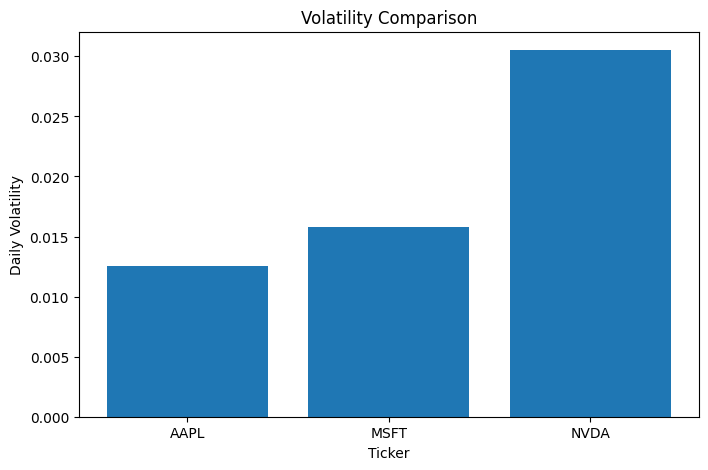

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(summary_table["Ticker"], summary_table["Volatility"])
plt.title("Volatility Comparison")
plt.xlabel("Ticker")
plt.ylabel("Daily Volatility")
plt.show()

# 19. Final Analysis Questions

Answer these questions in markdown:

1. Why do we use returns instead of raw stock prices?
2. Which stock had the highest average return?
3. Which stock had the highest volatility?
4. Which stock had the worst single-day return?
5. Which stock would be considered the riskiest?
6. If you were a conservative investor, which stock would you choose and why?
7. Why is rolling volatility more useful than one volatility number?

# 20. Final Mini Project

## Build a Risk Comparison Notebook

Choose any 3 stocks.

Examples:
- AAPL
- MSFT
- NVDA
- AMZN
- TSLA
- GOOG
- META

## Requirements

Your notebook must include:

1. Import libraries
2. Download stock data
3. Inspect the DataFrame
4. Check missing values
5. Check duplicates
6. Clean the data
7. Calculate daily returns
8. Calculate 20-day rolling volatility
9. Create a volatility plot
10. Create a summary table
11. Write 5 observations

## Expected Final Output

A completed notebook with:

- returns column
- rolling volatility column
- summary table
- chart
- written explanation